In [1]:
!pip install --upgrade scikit-learn joblib

1.Importing the dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

2.Data cleaning

In [3]:
# Load the dataset
df = pd.read_csv('loan_dataset_20000.csv')

# Handling missing values (if any)
df = df.dropna()

# Removing unnecessary columns if needed (e.g., ID columns, though not present here)
# Checking for duplicates
df = df.drop_duplicates()

3.Data visualization

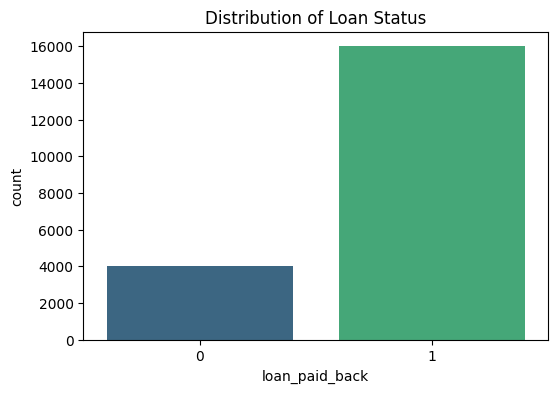

In [4]:
## 3. Data visualization
# Visualizing the target variable distribution
plt.figure(figsize=(6,4))

# Fixed: Added hue and legend=False to avoid the palette error
sns.countplot(x='loan_paid_back', data=df, hue='loan_paid_back', palette='viridis', legend=False)

plt.title('Distribution of Loan Status')
plt.show()

4.Exploratory Data Analysis (EDA)

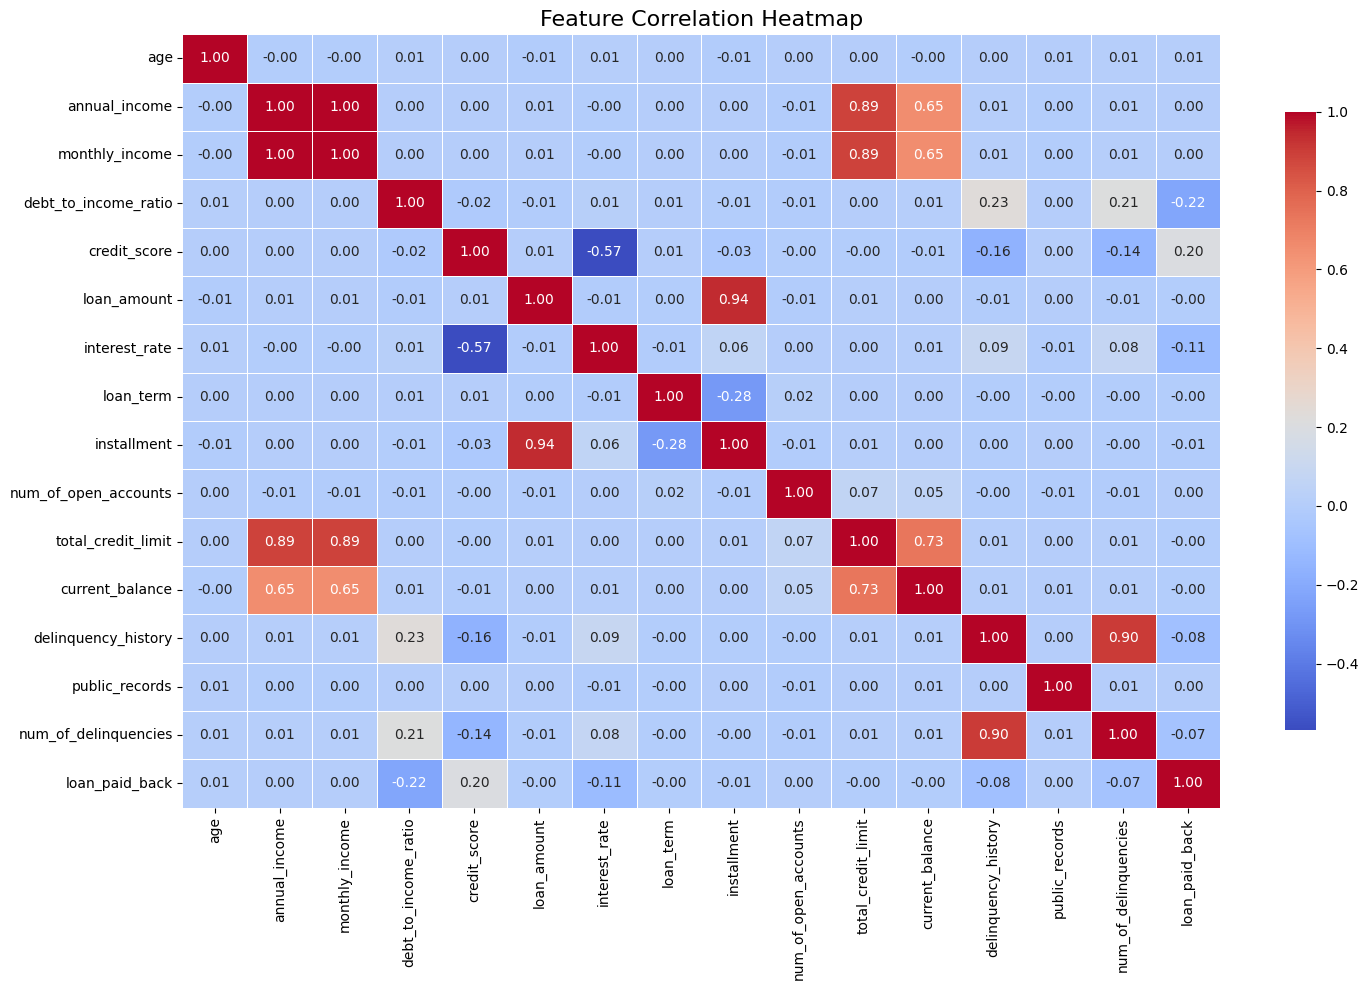

In [5]:
plt.figure(figsize=(15, 10)) # Bigger canvas

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Heatmap with better formatting
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5, # Boxes-kku naduvula gap kodukkum
            cbar_kws={"shrink": .8}) # Color bar-a konjam chinna akkum

plt.title('Feature Correlation Heatmap', fontsize=16)

# Fixing the "Cut-off" issue
plt.tight_layout()

plt.show()

5.Data Modeling (Preprocessing)

In [6]:
## 5. Data Modeling (Preprocessing Strategy)

# 1. Defining the Target Column
# Based on your dataset snippet, the target column name is 'loan_paid_back'
target_col = 'loan_paid_back'

# 2. Separating Features (X) and Target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# 3. Identifying Categorical and Numerical columns automatically
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# 4. Creating Preprocessing Transformers
# For Numerical: Fill missing with median and then Scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# For Categorical: Fill missing with most frequent and then One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 5. Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

print("Preprocessing Pipeline Defined Successfully.")
print(f"Numerical Columns: {list(numerical_cols)}")
print(f"Categorical Columns: {list(categorical_cols)}")

Preprocessing Pipeline Defined Successfully.
Numerical Columns: ['age', 'annual_income', 'monthly_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_term', 'installment', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies']
Categorical Columns: ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


6.Splitting the data into features and targets

In [7]:
## 6. Splitting the data into features and targets

# Verifying the split
print("Checking the shape of X and y:")
print(f"Total Rows in Dataset: {len(df)}")
print(f"Features (X) shape: {X.shape} (Should have one column less than original)")
print(f"Target (y) shape: {y.shape}")

# Visual check of the first few rows of Features
print("\nFirst 5 rows of Features (X):")
display(X.head())

Checking the shape of X and y:
Total Rows in Dataset: 20000
Features (X) shape: (20000, 21) (Should have one column less than original)
Target (y) shape: (20000,)

First 5 rows of Features (X):


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2


7.Splitting the data into test and training data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

8.Model training

In [9]:
# Define the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Create the full modeling pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

# Train the model
clf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

9.Model evaluation

In [10]:
y_pred = clf_pipeline.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.89425

Confusion Matrix:
 [[ 430  388]
 [  35 3147]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.53      0.67       818
           1       0.89      0.99      0.94      3182

    accuracy                           0.89      4000
   macro avg       0.91      0.76      0.80      4000
weighted avg       0.90      0.89      0.88      4000



10.Communication and Visualization

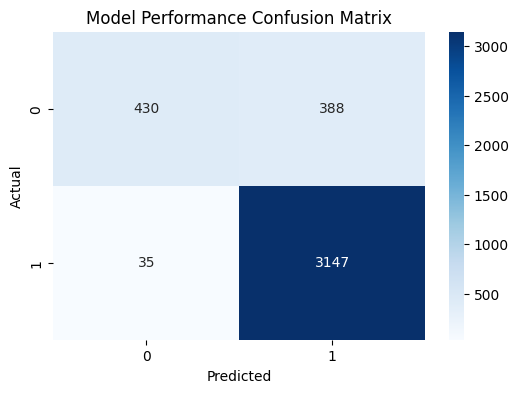

In [11]:
# Visualizing Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Model Performance Confusion Matrix')
plt.show()

11.Model saving

In [12]:
## 11. Model saving (.sav file with compression)
import joblib

# compress=9 kudutha maximum compression aagum.
# Idhu file size-a romba kammi pannidum.
joblib.dump(clf_pipeline, 'loan_model_pipeline.sav', compress=9)

print("Model saved successfully with compression!")

Model saved successfully with compression!


12.Pipeline Implementation

Automated Pipeline

In [13]:
# Example of a prediction function using the saved pipeline
def predict_loan_status(input_data):
    model_pipe = joblib.load('loan_model_pipeline.sav')
    prediction = model_pipe.predict(input_data)
    return "Approved" if prediction[0] == 1 else "Rejected"

13.Saving the Pipeline for Deployment

In [14]:
# (This is already achieved in Step 11 by saving the 'clf_pipeline' object)
print("Pipeline and Model successfully saved as .sav file.")

Pipeline and Model successfully saved as .sav file.
